# 01 · KITTI 데이터 확인 (Phase 1)

**목표**: 동기화된 KITTI RGB 프레임 1장과 LiDAR 프레임 1개를 읽고, 자료구조를 이해하고, 올바르게 시각화한다.

| 항목 | 내용 |
|---|---|
| 입력 | `image_02/data/0000000000.png` (왼쪽 컬러 카메라), `velodyne_points/data/0000000000.bin` |
| 출력 | 이미지 `(375, 1242, 3) uint8 BGR` · 점군 `(N, 4) float32 [x, y, z, reflectance]` |
| 좌표계 | 이미지: 픽셀 (u 우, v 아래, 원점 좌상단) · 점군: **Velodyne** (x 전방, y 좌, z 상, m) |
| 핵심 | OpenCV 는 BGR 순서 · `.bin` 은 float32 가 4개씩 연속 저장 · 같은 파일 번호 = 같은 시각 |
| 실패 사례 | 깨진 PNG, 크기가 16 바이트 배수가 아닌 `.bin`, RGB/BGR 혼동, 이미지-LiDAR 번호 불일치 |
| 평가 | shape/dtype/범위 출력, 프레임 id 집합 일치, `tests/test_kitti_loader.py` |

용어
- **동기화(sync) 시퀀스**: 카메라와 LiDAR(모두 10 Hz)를 같은 시각 기준으로 맞춰 같은 번호를 붙여 둔 데이터.
- **reflectance(반사 강도)**: 레이저가 되돌아온 세기. 0~1 로 정규화되며 재질·입사각에 따라 달라진다.

In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image, display

from perceptrack3d.config import load_config

cfg = load_config()                      # configs/kitti.yaml + 파생 경로 (절대경로를 코드에 쓰지 않는다)
ds = cfg["dataset"]
for k in ("root", "calib_dir", "drive_dir", "image_dir", "velo_dir", "tracklets"):
    print(f"{k:10s} {ds[k]}")

OUT = Path(cfg["outputs"]["dir"]) / "phase1"
OUT.mkdir(parents=True, exist_ok=True)
FRAME = 0
name = f"{FRAME:0{ds['frame_id_width']}d}"      # '0000000000'
img_path = Path(ds["image_dir"]) / f"{name}.png"
bin_path = Path(ds["velo_dir"]) / f"{name}.bin"
print(img_path.name, img_path.exists(), "|", bin_path.name, bin_path.exists())

root       /home/ingon/datasets/KITTI/raw
calib_dir  /home/ingon/datasets/KITTI/raw/2011_09_26
drive_dir  /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync
image_dir  /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/image_02/data
velo_dir   /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/velodyne_points/data
tracklets  /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/tracklet_labels.xml
0000000000.png True | 0000000000.bin True


## 1. 이미지 로드 — OpenCV 는 BGR

`cv2.imread` 는 PNG 를 `(H, W, 3)` `uint8` 배열로 읽는데 채널 순서가 **B, G, R** 이다 (초기 카메라/윈도우 비트맵 관례를 그대로 따른 역사적 이유).
matplotlib·PIL·PyTorch·YOLO 는 **R, G, B** 를 기대하므로, 표시하거나 모델에 넣기 전에 `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` 가 필요하다.
반대로 `cv2.imwrite` 는 BGR 배열을 기대하므로 RGB 배열을 그대로 저장하면 색이 뒤바뀐다.

- `shape = (H, W, C)`: 높이(행) → 너비(열) → 채널 순서. `img[v, u]` 처럼 **행(v)이 먼저** 온다.

In [2]:
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
print("shape :", img_bgr.shape, "  # (H, W, C) = (높이, 너비, 채널)")
print("dtype :", img_bgr.dtype)
print("range :", img_bgr.min(), "~", img_bgr.max())
print("채널별 평균 [B, G, R]:", img_bgr.reshape(-1, 3).mean(0).round(1))
print("좌상단 픽셀 img[0, 0] = [B, G, R]:", img_bgr[0, 0])

shape : (375, 1242, 3)   # (H, W, C) = (높이, 너비, 채널)
dtype : uint8
range : 0 ~ 255
채널별 평균 [B, G, R]: [87.6 91.7 81.1]
좌상단 픽셀 img[0, 0] = [B, G, R]: [147 137  58]


In [3]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].imshow(img_bgr); axes[0].set_title("WRONG: BGR array passed to imshow (sky turns orange)")
axes[1].imshow(img_rgb); axes[1].set_title("RIGHT: cv2.COLOR_BGR2RGB then imshow")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

# 저장: cv2.imwrite 는 BGR 을 기대하므로 원본 BGR 배열을 그대로 준다 → 파일은 정상 색으로 저장됨
rgb_out = OUT / "frame0_rgb.png"
cv2.imwrite(str(rgb_out), img_bgr)
print("saved:", rgb_out)

saved: /home/ingon/study/PercepTrack3D/outputs/phase1/frame0_rgb.png


/tmp/ipykernel_192095/1127261696.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 2. LiDAR `.bin` 로드 — float32 × 4 의 연속 저장

Velodyne HDL-64E 한 스캔(360° 한 바퀴)은 **헤더 없는 이진 파일**로, `float32` 값이
`x, y, z, r, x, y, z, r, ...` 순으로 이어져 있다. 따라서 파일 크기는 **16 바이트의 배수**여야 하고,
`np.fromfile(..., dtype=np.float32).reshape(-1, 4)` 로 `(N, 4)` 를 얻는다. `-1` 은 "나머지 축 크기는 알아서 계산" 이라는 뜻.

| 열 | 의미 | 단위 / 범위 |
|---|---|---|
| x | 전방 거리 | m (음수 = 차 뒤쪽) |
| y | 좌측 거리 | m (음수 = 오른쪽) |
| z | 위쪽 높이 (센서 원점 기준, 지면 ≈ −1.7 m) | m |
| reflectance | 반사 강도 | 0 ~ 1 |

좌표계는 **Velodyne 프레임** (x 전방, y 좌, z 상, 오른손 좌표계)이고 원점은 LiDAR 센서 중심(지상 약 1.73 m).

In [4]:
n_bytes = bin_path.stat().st_size
print("file bytes:", n_bytes, "| 16 의 배수?", n_bytes % 16 == 0, "| 예상 점 수:", n_bytes // 16)

raw = np.fromfile(str(bin_path), dtype=np.float32)
print("raw shape :", raw.shape, raw.dtype)
points = raw.reshape(-1, 4)
print("points    :", points.shape, points.dtype)
print("첫 3 점 [x, y, z, r]:")
print(points[:3])

print(f"\n{'col':14s}{'min':>9s}{'max':>9s}{'mean':>9s}")
for i, c in enumerate(["x (forward)", "y (left)", "z (up)", "reflectance"]):
    col = points[:, i]
    print(f"{c:14s}{col.min():9.2f}{col.max():9.2f}{col.mean():9.2f}")
r = np.linalg.norm(points[:, :3], axis=1)
print(f"\n거리 r: min {r.min():.2f} m, max {r.max():.2f} m, median {np.median(r):.2f} m")
print("앞쪽(x > 0) 점 비율:", round(float((points[:, 0] > 0).mean()), 3), " (카메라는 앞쪽만 보므로 뒤쪽 점은 투영에서 버려진다)")

file bytes: 1981424 | 16 의 배수? True | 예상 점 수: 123839
raw shape : (495356,) float32
points    : (123839, 4) float32
첫 3 점 [x, y, z, r]:
[[48.373 11.554  1.891  0.1  ]
 [48.37  11.714  1.892  0.   ]
 [68.748 25.163  2.685  0.   ]]

col                 min      max     mean
x (forward)      -78.94    78.08    -0.48
y (left)         -69.12    71.37     0.80
z (up)            -3.47     2.85    -1.29
reflectance        0.00     0.99     0.27

거리 r: min 1.47 m, max 79.88 m, median 12.78 m
앞쪽(x > 0) 점 비율: 0.51  (카메라는 앞쪽만 보므로 뒤쪽 점은 투영에서 버려진다)


## 3. 동기화 확인 — 같은 번호는 같은 시각

`image_02/data/0000000000.png` 와 `velodyne_points/data/0000000000.bin` 은 같은 프레임이다.
확인 방법 두 가지:
1. 두 폴더의 파일 번호 집합이 같고 0 부터 빠짐없이 이어지는지.
2. 각 센서 폴더의 `timestamps.txt` 의 같은 줄이 같은 시각인지. LiDAR 의 `timestamps.txt` 는 스캐너가 정면(카메라 방향)을 향한 순간이며,
   이 순간 카메라가 트리거된다 (`timestamps_start/end.txt` 는 한 바퀴 회전의 시작/끝). 그래서 두 값이 수 ms 안에서 일치해야 한다.

In [5]:
image_dir, velo_dir = Path(ds["image_dir"]), Path(ds["velo_dir"])
png_ids = sorted(int(p.stem) for p in image_dir.glob("*.png"))
bin_ids = sorted(int(p.stem) for p in velo_dir.glob("*.bin"))
print("PNG 수:", len(png_ids), " BIN 수:", len(bin_ids))
print("id 집합 동일?", set(png_ids) == set(bin_ids), "| 범위:", png_ids[0], "~", png_ids[-1])
print("연속(빠진 번호 없음)?", png_ids == list(range(len(png_ids))))

ts_img = (image_dir.parent / "timestamps.txt").read_text().splitlines()
ts_vel = (velo_dir.parent / "timestamps.txt").read_text().splitlines()
from datetime import datetime
def parse(s):  # 'YYYY-MM-DD HH:MM:SS.nnnnnnnnn' → 나노초를 마이크로초로 잘라 파싱
    return datetime.strptime(s[:26], "%Y-%m-%d %H:%M:%S.%f")
for i in (0, 1, 296):
    dt_ms = (parse(ts_img[i]) - parse(ts_vel[i])).total_seconds() * 1e3
    print(f"frame {i:3d}: image_02 {ts_img[i][11:]} | velodyne {ts_vel[i][11:]} | diff {dt_ms:+.1f} ms")
fps = 1.0 / (parse(ts_img[1]) - parse(ts_img[0])).total_seconds()
print(f"프레임 간격 ≈ {1000/fps:.1f} ms → 약 {fps:.1f} Hz")

PNG 수: 297  BIN 수: 297
id 집합 동일? True | 범위: 0 ~ 296
연속(빠진 번호 없음)? True
frame   0: image_02 13:12:03.957664256 | velodyne 13:12:03.947134816 | diff +10.5 ms
frame   1: image_02 13:12:04.061060352 | velodyne 13:12:04.050539302 | diff +10.5 ms
frame 296: image_02 13:12:34.611652352 | velodyne 13:12:34.601085621 | diff +10.6 ms
프레임 간격 ≈ 103.4 ms → 약 9.7 Hz


## 4. 시각화 ① BEV (bird's-eye view, 위에서 내려다본 x-y 평면)

3D 점군을 이해하는 가장 쉬운 방법은 높이(z)를 색으로 두고 위에서 내려다보는 것이다.
그림은 **x(전방)가 위쪽, y(좌)가 왼쪽**이 되도록 가로축을 `-y` 로 잡는다. 검은 삼각형이 우리 차(센서) 위치.
색 범위는 −2.5 ~ +2.5 m 로 고정해 두어 다른 프레임과 비교할 때 색의 의미가 같도록 한다.

saved: /home/ingon/study/PercepTrack3D/outputs/phase1/frame0_pointcloud_bev.png


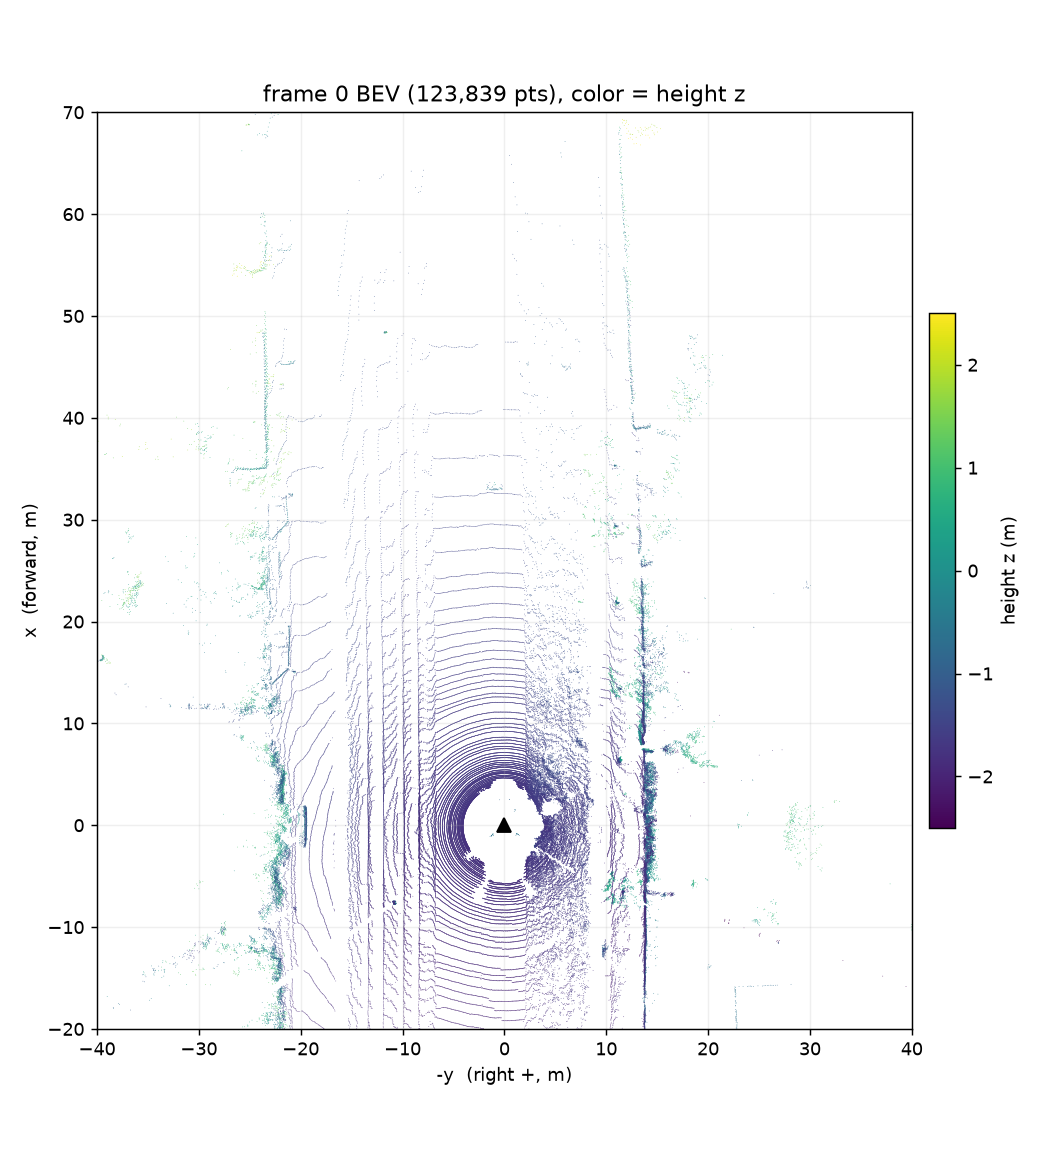

In [6]:
from perceptrack3d.visualization.pointcloud import plot_bev, plot_3d_scatter

bev_out = plot_bev(points, OUT / "frame0_pointcloud_bev.png", title=f"frame {FRAME} BEV ({len(points):,} pts), color = height z")
print("saved:", bev_out)
display(Image(filename=str(bev_out), width=700))

## 4. 시각화 ② 3D 산점도 (matplotlib)

점이 12만 개라 전부 그리면 느리므로, **seed 를 고정한 무작위 부표본**(60,000 점)만 그린다 (재현성 규칙).
도로면(어두운 색, z ≈ −1.7 m)이 평평하게 깔리고 건물·차량이 위로 솟는 구조가 보이면 정상이다.

saved: /home/ingon/study/PercepTrack3D/outputs/phase1/frame0_pointcloud_3d.png


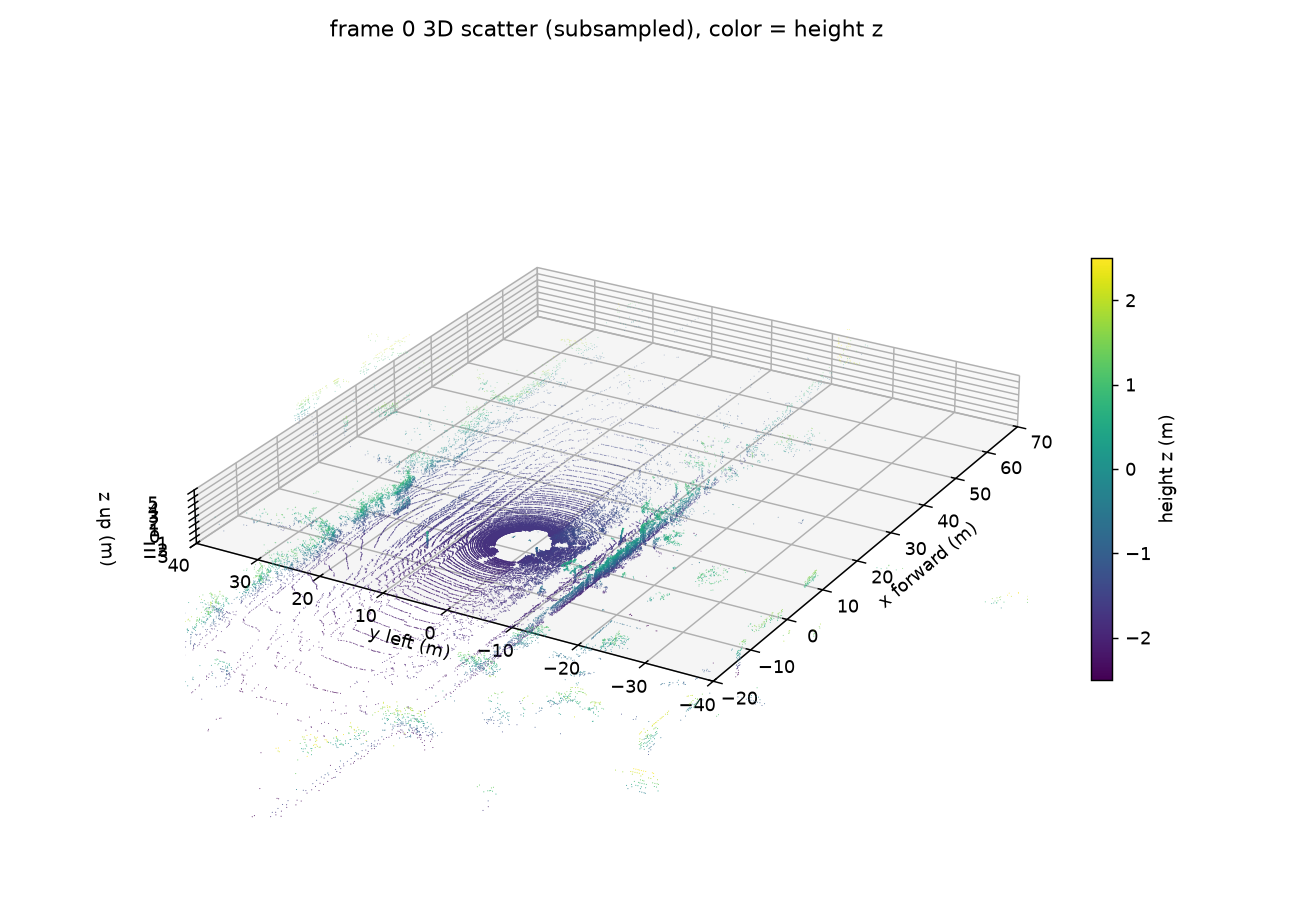

In [7]:
sc_out = plot_3d_scatter(points, OUT / "frame0_pointcloud_3d.png", title=f"frame {FRAME} 3D scatter (subsampled), color = height z")
print("saved:", sc_out)
display(Image(filename=str(sc_out), width=800))

## 4. 시각화 ③ Open3D — PLY 저장과 오프스크린 렌더링

Open3D 의 `PointCloud` 로 바꾸면 PLY 로 저장해 MeshLab·CloudCompare 에서 열어볼 수 있고, 뒤 단계(지면 제거·클러스터링)에서도 그대로 쓴다.
WSL 은 창을 띄우기 어려우므로 `OffscreenRenderer` (EGL headless) 로 이미지 파일만 만든다. 실패하면 위의 matplotlib 결과를 쓰면 된다.

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


PointCloud with 123839 points.
min bound: [-78.94 -69.12  -3.47]  max bound: [78.08 71.37  2.85]
saved: /home/ingon/study/PercepTrack3D/outputs/phase1/frame0.ply (3265 KB)
[Open3D INFO] EGL headless mode enabled.


libEGL warning: pci id for fd 88: 10de:2782, driver (null)

pci id for fd 89: 10de:2782, driver (null)
pci id for fd 90: 10de:2782, driver (null)
libEGL warning: egl: failed to create dri2 screen
pci id for fd 89: 10de:2782, driver (null)
pci id for fd 90: 10de:2782, driver (null)
libEGL warning: egl: failed to create dri2 screen


Open3D offscreen render saved: /home/ingon/study/PercepTrack3D/outputs/phase1/frame0_pointcloud_o3d.png


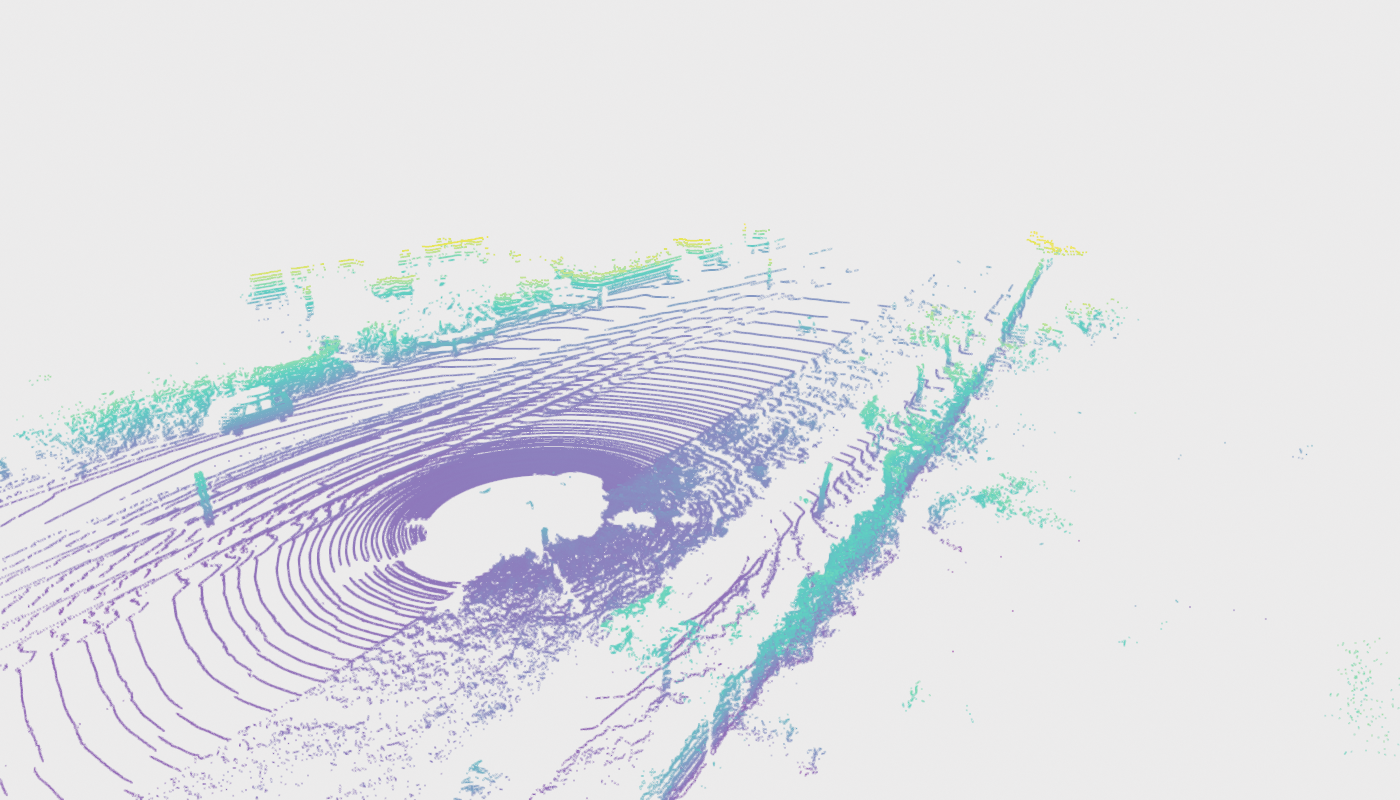

In [8]:
import open3d as o3d
import matplotlib
from perceptrack3d.visualization.pointcloud import to_open3d_pointcloud, save_ply

pcd = to_open3d_pointcloud(points)
print(pcd)
print("min bound:", np.asarray(pcd.get_min_bound()).round(2), " max bound:", np.asarray(pcd.get_max_bound()).round(2))
ply_out = save_ply(points, OUT / "frame0.ply")
print("saved:", ply_out, f"({ply_out.stat().st_size // 1024} KB)")

# 높이 z 를 viridis 색으로 (−2.5 ~ 2.5 m 고정 범위)
t = np.clip((points[:, 2] + 2.5) / 5.0, 0.0, 1.0)
pcd.colors = o3d.utility.Vector3dVector(matplotlib.colormaps["viridis"](t)[:, :3])

o3d_out = OUT / "frame0_pointcloud_o3d.png"
try:
    renderer = o3d.visualization.rendering.OffscreenRenderer(1400, 800)
    renderer.scene.set_background([1.0, 1.0, 1.0, 1.0])
    mat = o3d.visualization.rendering.MaterialRecord()
    mat.shader = "defaultUnlit"
    mat.point_size = 2.0
    renderer.scene.add_geometry("pcd", pcd, mat)
    renderer.setup_camera(55.0, [15.0, 0.0, -1.0], [-22.0, -22.0, 14.0], [0.0, 0.0, 1.0])  # (fov, center, eye, up)
    o3d.io.write_image(str(o3d_out), renderer.render_to_image())
    print("Open3D offscreen render saved:", o3d_out)
    display(Image(filename=str(o3d_out), width=900))
except Exception as e:
    print("Open3D 오프스크린 렌더링 실패 → matplotlib 결과로 대체:", type(e).__name__, e)

In [9]:
# 직접 실행해보기 (GUI 가 되는 환경에서만): 마우스로 돌려볼 수 있는 창이 뜬다.
# o3d.visualization.draw_geometries([pcd], window_name="KITTI frame 0")

## 5. 모듈로 재사용 — `perceptrack3d.data.kitti_loader`

위에서 손으로 한 로딩 로직은 `src/perceptrack3d/data/kitti_loader.py` 에 정리되어 있다.
`KittiDataset` 은 설정 파일에서 경로를 만들고, `load_image` / `load_velodyne` 은 **잘못된 파일을 명확한 예외로 거부**한다.
아래에서 같은 결과가 나오는지, 그리고 깨진 입력이 걸러지는지 확인한다.

In [10]:
from perceptrack3d.data.kitti_loader import KittiDataset, load_image, load_velodyne
import tempfile

dataset = KittiDataset(cfg)
frame = dataset.load_frame(FRAME)
print(len(dataset), "frames, keys:", list(frame))
print("image :", frame["image"].shape, frame["image"].dtype)
print("points:", frame["points"].shape, frame["points"].dtype)
print("수동 로드와 동일?  image:", np.array_equal(frame["image"], img_bgr), " points:", np.array_equal(frame["points"], points))

with tempfile.TemporaryDirectory() as d:
    bad = Path(d) / "bad.bin"
    bad.write_bytes(b"\x00" * 17)                      # 16 의 배수가 아닌 크기
    try:
        load_velodyne(bad)
    except ValueError as e:
        print("ValueError        :", e)
    try:
        load_image(Path(d) / "nope.png")
    except FileNotFoundError as e:
        print("FileNotFoundError :", e)

297 frames, keys: ['frame_id', 'image', 'points', 'image_path', 'velodyne_path']
image : (375, 1242, 3) uint8
points: (123839, 4) float32
수동 로드와 동일?  image: True  points: True
ValueError        : LiDAR 파일 크기가 16 바이트(float32 x 4)의 배수가 아닙니다 (bytes=17): /tmp/tmpvuie50mr/bad.bin
FileNotFoundError : 이미지 파일이 없습니다: /tmp/tmpvuie50mr/nope.png


## 6. 정리

- **입력/출력**: PNG → `(375, 1242, 3) uint8 BGR`, BIN → `(N≈120k, 4) float32`.
- **좌표계**: 이미지는 `img[v, u]` (행이 먼저), 점군은 Velodyne (x 전방, y 좌, z 상, m).
- **실패 사례**: BGR 을 RGB 로 착각하면 하늘이 주황색 · `.bin` 끝이 잘리면 `np.fromfile` 은 조용히 자투리를 버리므로 **바이트 수를 먼저 검사**해야 함 · 번호가 같은 파일이 없으면 동기화가 깨진 것.
- **평가**: `tests/test_kitti_loader.py` (shape/dtype, 예외, id 집합 일치).

### 자가 점검 질문
1. `img_bgr[100, 200]` 은 이미지의 어느 위치(가로/세로) 픽셀이며, 세 값의 순서는 무엇인가?
2. `.bin` 파일 크기가 1,981,424 바이트일 때 점의 개수는 몇 개이고, 왜 `reshape(-1, 4)` 가 가능한가?
3. Velodyne 프레임에서 `y = -3.0 m` 인 점은 차의 어느 쪽에 있는가? 지면 점의 z 는 대략 얼마인가?